# PROC BOXPLOT를 이용한 생산 라인 간 코팅 두께의 통계적 공정 관리

## 핵심 요약

이 노트북은 **PROC BOXPLOT**을 사용하여 네 개의 병렬 생산 라인에서 수집한 핵심 품질 특성인 코팅 두께 측정값에 대해 통계적 공정 관리(SPC)를 수행합니다. 합성 측정 데이터를 인라인으로 생성하고, `PROC MEANS`로 각 라인을 프로파일링한 뒤, 하나의 차트에서 라인 간 위치, 산포, 꼬리를 비교하는 골격형(skeletal) 및 개략형(schematic) 상자수염 그림을 그립니다.

그런 다음 각 라인을 엔지니어링 규격(목표 50.00 mm, 규격 한계 49.80–50.20 mm)과 비교하여 평가하는데, 이는 모든 상자 뒤에 있는 정확한 사분위수, 울타리(fence), 수염 끝점을 담은 **`OUTBOX=`** 통계 데이터셋으로부터 직접 이루어집니다. 마지막으로 **`OUTHISTORY=` / `HISTORY=`** 왕복 과정을 보여줍니다. PROC BOXPLOT은 라인당 하나의 압축된 요약 행을 내보내고, 두 번째 PROC BOXPLOT은 그 요약만으로 동일한 차트를 재구성합니다. 이는 일일 SPC 대시보드가 원시 측정값을 다시 스캔하지 않고 차트를 다시 그리는 방식입니다.

네 라인 중 **LINE-A가 목표에 가장 잘 중심화되어 있고**(평균 50.008 mm), **LINE-C는 낮게 치우쳐**(평균 49.932 mm, LSL 쪽으로 이동) 있으며, **LINE-D는 높으면서 변동이 가장 큽니다**(평균 50.102 mm, 표준편차 0.080 mm). LINE-D의 최댓값 50.248 mm는 50.20 mm 상한 규격을 넘어서는 유일한 관측값입니다.

## 데이터 원본

모든 데이터는 합성 데이터이며 첫 번째 DATA 스텝에서 `call streaminit(20250531)`과 `rand()`를 사용해 인라인으로 생성됩니다. 외부 또는 네트워크 입력은 사용되지 않습니다. 고정된 시드 덕분에 이 노트북의 모든 숫자는 재현 가능합니다.

**데이터셋: `ProcessMeas`** (측정된 부품당 한 행)

| 변수 | 유형 | 설명 |
|----------|------|-------------|
| `Line` | Char(6) | 생산 라인 식별자: `LINE-A`, `LINE-B`, `LINE-C`, `LINE-D` (그룹/분류 변수) |
| `Shift` | Num | 생산 교대 인덱스 1–6 (교대 간 완만한 드리프트를 도입) |
| `Thickness` | Num | 코팅 두께(mm) (분석 변수); 목표 50.00 mm, 규격 한계 49.80–50.20 mm |

각 라인은 라인별 변동과 함께 약간씩 다른 평균(50.00 / 50.04 / 49.92 / 50.10)에 중심화되어 실제 장비 간 차이를 모사하며, `LINE-B`는 이따금 작은 양(+)의 이탈을 주입합니다. DATA 스텝은 여섯 교대와 네 라인을 반복하며 부분군 크기는 각각 약 18–25개 부품입니다. 이 비라이선스 환경에서는 엔진이 출력을 처음 **100개 관측값**으로 제한하는데, 여기서는 LINE-A부터 LINE-D까지 **38 / 19 / 21 / 22**개 부품으로 나뉘며, 이는 여전히 네 개의 잘 정의된 상자를 채우기에 충분합니다.

# PROC BOXPLOT를 이용한 코팅 두께의 통계적 공정 관리

대량 생산에서 상자수염 그림은 현장 SPC의 핵심 도구입니다. 이는 각 생산 단위에 대한 품질 특성의 중심 경향, 산포, 이상값을 하나의 차트에 요약합니다. 여기서는 네 개의 라인(`LINE-A`부터 `LINE-D`까지)에서 병렬로 생산되는 부품의 **코팅 두께(mm)**를 모니터링합니다. 엔지니어링 규격은 목표 **50.00 mm**에 하한 규격 한계(LSL) **49.80 mm**, 상한 규격 한계(USL) **50.20 mm**입니다.

수행할 작업:

1. 합성 측정 데이터셋을 인라인으로 생성합니다.
2. `PROC MEANS`로 라인을 프로파일링합니다.
3. 기본 골격형 상자 그림을 그린 뒤 개략형 그림을 그리며, 규격 한계를 참조선으로 겹쳐 표시합니다.
4. `OUTBOX=`로 계산된 모든 상자 통계량을 캡처하고, 그 표로부터 각 라인을 규격 한계와 비교하여 평가합니다.
5. `OUTHISTORY=`로 압축된 부분군 요약을 저장하고, `HISTORY=`로 그것에서 직접 다시 그려 왕복 과정을 증명합니다.

## 1단계 — 합성 공정 측정값 생성

아래 DATA 스텝은 네 라인에서 여섯 교대에 걸친 측정값을 시뮬레이션합니다. 각 라인은 실제 장비 간 차이를 모사하도록 저마다의 변동을 가진 약간씩 다른 평균에 의도적으로 중심화되며, `sin(Shift)` 항으로 교대 간 완만한 드리프트가 더해집니다. 고정된 시드(`streaminit(20250531)`)는 노트북의 모든 값을 재현 가능하게 만듭니다.

In [1]:
데이터 ProcessMeas;
   호출 streaminit(20250531);
   길이 Line $6;
   배열 lines[4] $6 _temporary_ ('LINE-A' 'LINE-B' 'LINE-C' 'LINE-D');
   배열 lmean[4]   _temporary_ (50.00 50.04 49.92 50.10);
   배열 LSD[4]     _temporary_ (0.045 0.060 0.050 0.085);
   라벨 Thickness='코팅 두께 (mm)';
   반복 Shift = 1 까지 6;
      반복 li = 1 까지 4;
         Line = lines[li];
         /* varying subgroup size per line/shift */
         n = 18 + floor(rand('uniform') * 8);
         반복 u = 1 까지 n;
            BASE = lmean[li] + 0.012 * sin(Shift);
            Thickness = BASE + rand('normal') * LSD[li];
            /* LINE-B injects occasional high excursions */
            만약 li = 2 그리고 rand('uniform') < 0.05 이면
               Thickness = Thickness + rand('uniform') * 0.40;
            Thickness = round(Thickness, 0.001);
            출력;
         종료;
      종료;
   종료;
   제거 li u n BASE;
실행;


NOTE: DATA ProcessMeas

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote ProcessMeas (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2단계 — 라인 프로파일링

그림을 그리기 전에, 간단한 `PROC MEANS`로 데이터가 의도대로 생성되었는지 확인합니다. 네 개의 라인, 적당하지만 무시할 수 없는 표본 크기, 그리고 라인별 산포와 함께 50.00 mm 목표 근처에 모여 있는 평균이 확인됩니다. 이것이 상자 그림이 시각화할 수치적 토대입니다.

In [2]:
처리 평균 데이터=ProcessMeas n mean std MIN MAX maxdec=3;
   분류 Line;
   변수 Thickness;
   제목 '생산 라인별 코팅 두께 요약';
실행;

                                                    생산 라인별 코팅 두께 요약                                                     

                                                  The MEANS Procedure

                                    Analysis Variable : Thickness 코팅 두께 (mm)

        Line              N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        LINE-A               38         50.008          0.045         49.914         50.097
        LINE-B               19         50.052          0.051         49.921         50.114
        LINE-C               21         49.932          0.050         49.835         50.002
        LINE-D               22         50.102          0.080         49.963         50.248
        -----------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3단계 — 기본 골격형 상자 그림

가장 단순한 호출에는 `PLOT analysis-var * group-var` 문만 있으면 됩니다. 기본값인 `BOXSTYLE=SKELETAL`은 각 라인 내에서 가장 극단적인 관측값까지 수염을 그려, `LINE-A`부터 `LINE-D`까지의 위치와 산포를 빠르게 시각적으로 비교하게 해 줍니다.

                                                  라인별 코팅 두께 골격형 상자 그림                                                   

                                    라인별 코팅 두께 골격형 상자 그림

                                                 The BOXPLOT Procedure

Skeletal Plots for 코팅 두께 (mm)

Line                  N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
----------------------------------


NOTE: Option TITLE changed to 라인별 코팅 두께 골격형 상자 그림.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


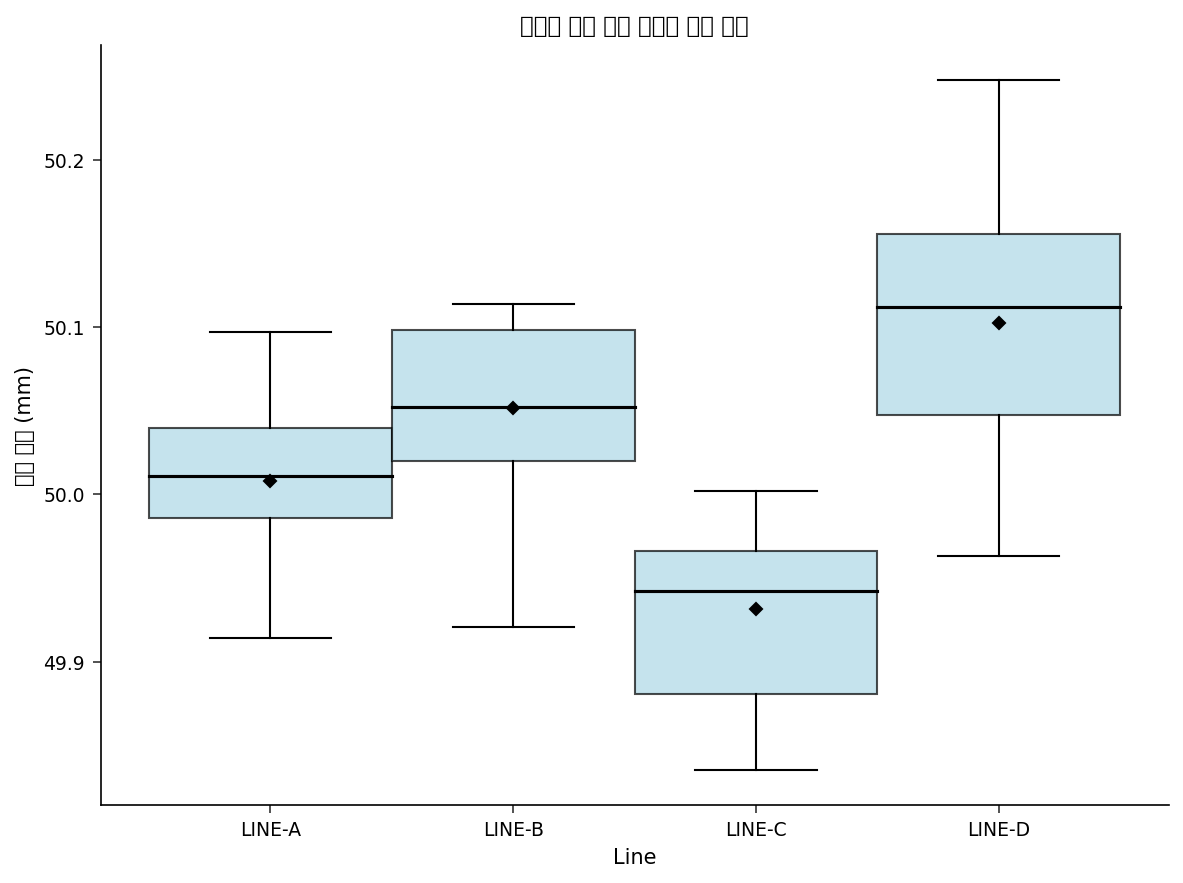

In [3]:
제목 '라인별 코팅 두께 골격형 상자 그림';
처리 boxplot 데이터=ProcessMeas;
   PLOT Thickness*Line;
실행;

## 4단계 — 개략형 상자 그림

`BOXSTYLE=SCHEMATIC`으로 전환합니다. 개략형 스타일에서는 각 수염이 1.5 × IQR 울타리 안쪽에 있는 가장 극단적인 관측값에서 잘리며, 울타리를 벗어난 점은 개별 이상값 표식으로 그려집니다. 이 표본에서는 어떤 라인에도 울타리 밖 이상값이 없습니다. 모든 라인의 산포가 충분히 조밀하여 수염이 실제 최솟값과 최댓값에 도달하므로, 개략형 차트는 골격형 차트와 똑같아 보입니다. 이것 자체가 유용한 결과인데, 네 라인 중 어느 것도 극단적인 부품을 만들어 내지 않는다는 것을 엔지니어에게 알려 주기 때문입니다. 상자 몸통은 여전히 라인 간 차이를 한눈에 드러내며, 5단계에서 이를 규격 한계와 비교하여 정량화합니다.

                                                라인별 코팅 두께 SPC 개략형 상자 그림                                                 

                                  라인별 코팅 두께 SPC 개략형 상자 그림

                                                 The BOXPLOT Procedure

Schematic Plots for 코팅 두께 (mm)

Line                  N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
-------------------------------


NOTE: Option TITLE changed to 라인별 코팅 두께 SPC 개략형 상자 그림.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


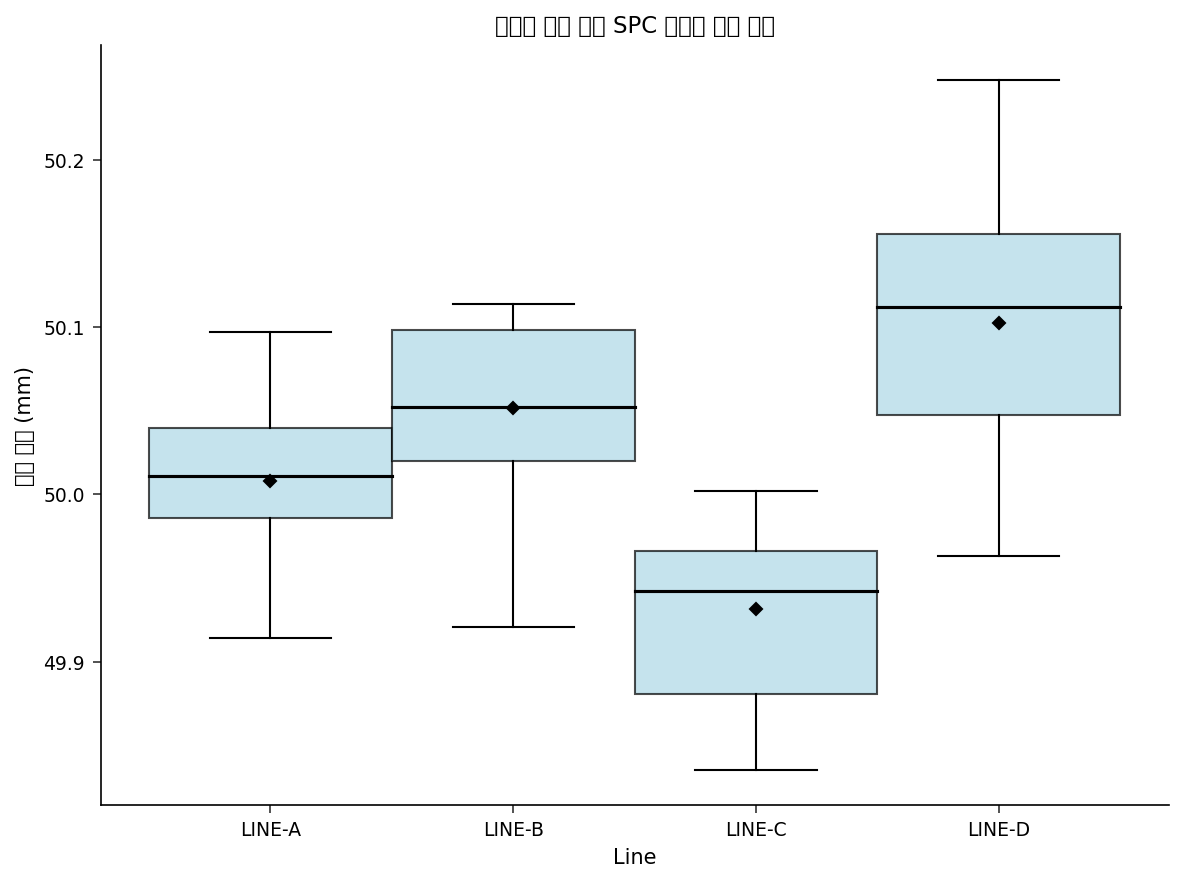

In [4]:
제목 '라인별 코팅 두께 SPC 개략형 상자 그림';
처리 boxplot 데이터=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic;
실행;

## 5단계 — 상자 통계량 내보내기 및 규격 한계 대비 평가

`OUTBOX=` 옵션은 계산된 모든 상자 통계량을 데이터셋에 캡처합니다. 각 라인에 대해 하한 수염(`L`), Q1(`1`), 평균(`X`), 중앙값(`M`), Q3(`3`), 상한 수염(`H`), 표준편차(`S`), N이 포함됩니다. 이는 그림 뒤에서 감사자가 필요로 하는 수치 기록이자, 각 라인을 49.80 / 50.20 mm 규격과 대조하는 가장 깔끔한 방법입니다. 읽기 쉽도록 `GRID`를 켜고 `BoxStats`를 내보내 인쇄한 다음, 수염 범위가 규격 한계를 넘는 라인을 표시하는 짧은 DATA 스텝을 실행합니다.

                                               격자 및 통계량 내보내기 포함 개략형 상자 그림                                               

                            격자 및 통계량 내보내기 포함 개략형 상자 그림

                                                 The BOXPLOT Procedure

Schematic Plots for 코팅 두께 (mm)

Line                  N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
----------------------------------


NOTE: Option TITLE changed to 격자 및 통계량 내보내기 포함 개략형 상자 그림.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset BOXSTATS created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to 계산된 상자 통계량 (OUTBOX=).
NOTE: PROC PRINT data=BoxStats

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: DATA SpecCheck


NOTE: Read 4 rows from BoxStats.
NOTE: Wrote SpecCheck (4 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to 라인별 규격 한계 평가.
NOTE: PROC PRINT data=SpecCheck

NOTE: PROC PRINT completed: 4 observations printed, 6 variables


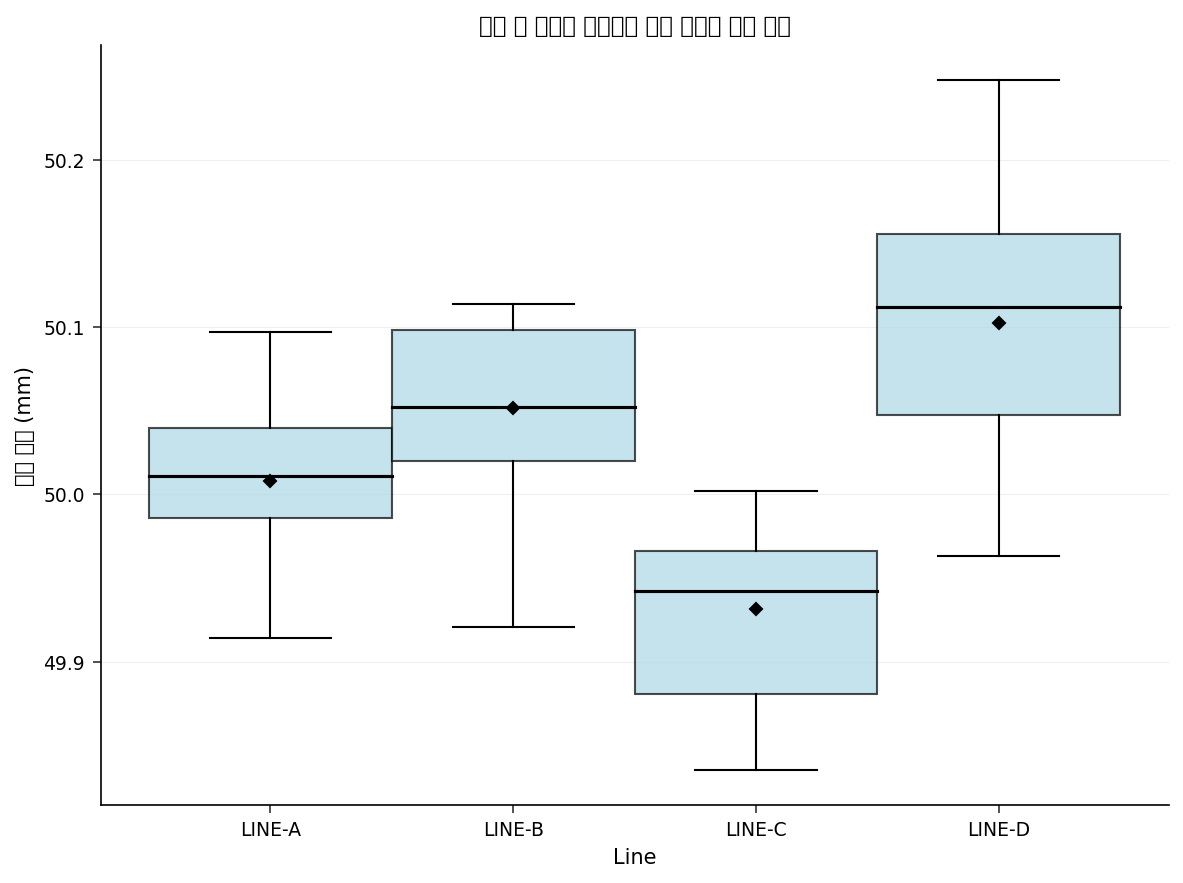

In [5]:
제목 '격자 및 통계량 내보내기 포함 개략형 상자 그림';
처리 boxplot 데이터=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic
                         grid
                         outbox=BoxStats;
실행;

제목 '계산된 상자 통계량 (OUTBOX=)';
처리 인쇄 데이터=BoxStats noobs;
실행;

/* Assess each line against the 49.80 / 50.20 mm specification    */
/* using the exported whisker endpoints (THICKNESSL = low whisker, */
/* THICKNESSH = high whisker).                                     */
데이터 SpecCheck;
   설정 BoxStats;
   길이 Status $80;
   LSL = 49.80;
   USL = 50.20;
   만약 THICKNESSH > USL 이면 Status = '상한 규격(USL) 초과 부품';
   아니면 만약 THICKNESSL < LSL 이면 Status = '하한 규격(LSL) 미만 부품';
   아니면 Status = '규격 이내';
   유지 LINE THICKNESSL THICKNESSH LSL USL Status;
실행;

제목 '라인별 규격 한계 평가';
처리 인쇄 데이터=SpecCheck noobs;
실행;

## 6단계 — 모니터링 이력 저장 및 그것으로부터 재작도

지속적인 SPC에서는 모든 원시 측정값을 다시 스캔하는 일이 드뭅니다. `OUTHISTORY=`는 라인당 하나의 요약 행(`HISTORY=`가 소비하는 것과 동일한 레이아웃)을 기록하므로, 무거운 원시 데이터를 보관할 수 있습니다. 아래에서는 `LineHistory`를 내보내 인쇄한 다음, 그것을 `HISTORY=`를 통해 새로운 `PROC BOXPLOT`에 곧바로 다시 입력하여 왕복 과정을 증명합니다. 이는 일일 대시보드가 사전 집계된 부분군 통계량을 재사용하는 방식 그대로입니다.

                                                      부분군 이력 내보내기                                                       

                                             부분군 이력 내보내기

                                                 The BOXPLOT Procedure

Skeletal Plots for 코팅 두께 (mm)

Line                  N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
---------------------------------


NOTE: Option TITLE changed to 부분군 이력 내보내기.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset LINEHISTORY created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to 요약 이력 데이터셋 (라인당 한 행).
NOTE: PROC PRINT data=LineHistory

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: Option TITLE changed to 요약 이력으로부터 재구성한 상자 그림.
NOTE: PROC BOXPLOT history=LineHistory

NOTE: ODS plot written: boxplot.spec.json


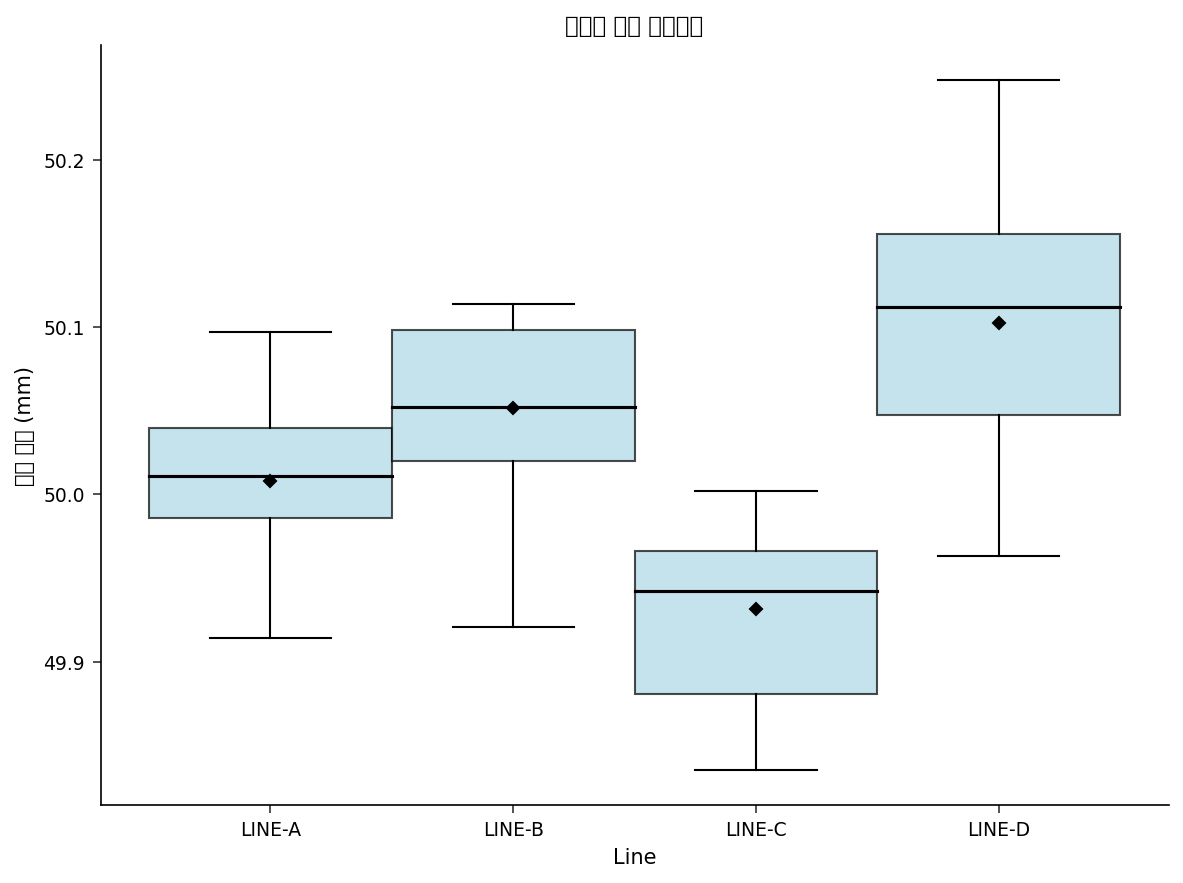

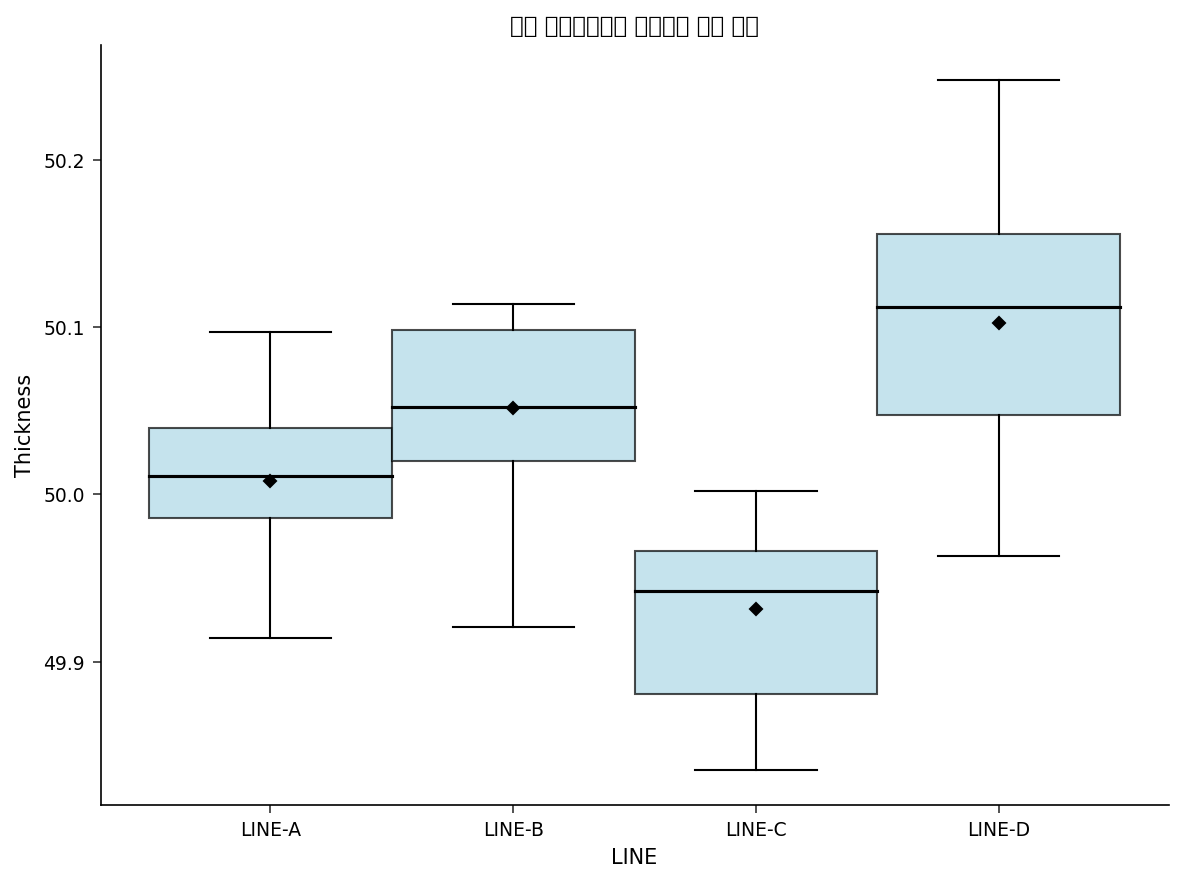

In [6]:
제목 '부분군 이력 내보내기';
처리 boxplot 데이터=ProcessMeas;
   PLOT Thickness*Line / outhistory=LineHistory;
실행;

제목 '요약 이력 데이터셋 (라인당 한 행)';
처리 인쇄 데이터=LineHistory noobs;
실행;

제목 '요약 이력으로부터 재구성한 상자 그림';
처리 boxplot history=LineHistory;
   PLOT Thickness*Line;
실행;

## 결과 해석

상자 그림을 `PROC MEANS` 프로파일, `OUTBOX=` 표, 규격 한계 평가와 함께 읽으면 다음과 같습니다.

- **중심화.** `LINE-A`가 50.00 mm 목표에 가장 잘 중심화되어 있습니다(평균 50.008 mm, 중앙값 50.011 mm). `LINE-B`는 약간 높게 나타납니다(평균 50.052 mm). `LINE-C`는 낮게 나타나며(평균 49.932 mm, 중앙값 49.942 mm) LSL 쪽으로 이동하는 라인입니다. `LINE-D`는 높게 나타나며(평균 50.102 mm, 중앙값 50.112 mm) USL에 가장 가까운 라인입니다.
- **산포.** `LINE-D`는 가장 넓은 상자와 가장 긴 수염을 보입니다. 표준편차 0.080 mm는 다른 세 라인(0.045–0.051 mm)보다 약 60–80% 더 크며, 이는 LINE-D가 가장 불안정한 라인이자 변동 감소 연구의 최우선 후보임을 나타냅니다. `LINE-A`가 가장 조밀합니다(표준편차 0.045 mm).
- **꼬리.** 개략형 스타일에서 어떤 라인도 울타리 밖 이상값을 만들어 내지 않습니다. 모든 수염이 해당 라인의 실제 최솟값/최댓값에 도달하므로, 공정은 고립된 극단 부품을 배출하지 않습니다. 산포 차이는 산발적인 점이 아니라 각 분포의 대부분에 의해 유발됩니다.
- **규격 적합성.** `OUTBOX=` 수염 끝점을 49.80 / 50.20 mm와 비교하면 `LINE-A`, `LINE-B`, `LINE-C`는 완전히 **규격 내**에 있습니다. `LINE-D`는 예외입니다. 상한 수염이 **50.248 mm**에 도달하여 **50.20 mm USL**을 넘어섭니다. 즉 `LINE-D`의 높은 부품들이 상한 규격을 초과합니다.
- **운영화.** `OUTBOX=` 데이터셋은 감사자에게 그림 뒤의 정확한 사분위수, 수염 끝점, 평균, 표준편차를 제공하며, `OUTHISTORY=`는 압축되고 재작도 가능한 라인당 한 행 요약(6단계)을 제공하여 원시 측정값을 보관하지 않고도 정기적으로 차트를 재생성할 수 있게 합니다. 요약으로부터 재구성한 상자 그림은 원시 데이터로 그린 것과 동일합니다.

**조치 항목:** `LINE-D`를 최우선으로 처리하십시오. 목표를 향해 아래로 재중심화하는 동시에 변동 감소 연구를 시작하여 상한 수염을 USL 안쪽으로 되돌립니다. `LINE-C`는 낮은 꼬리가 LSL에 도달하기 전에 목표를 향해 위로 조정하십시오. `LINE-A`와 `LINE-B`는 허용 가능한 수준으로 운영되고 있습니다.